What is LangGraph?
  * LangGraph is an open-source Python library built on top of LangChain that allows you to create stateful, graph-based workflows for AI applications.
  * Unlike traditional linear chains in LangChain, LangGraph models interactions as a graph, where "Nodes" represent actions (e.g., calling an LLM, using a tool) and "Edges" define How to move between them.

  * This is particularly useful for applications requiring state management, cycles, or complex decision-making.

Key Components:

  * Nodes: Individual steps or actions (e.g., call an LLM, execute a tool).
  * Edges: Connections between nodes, defining the flow (can be conditional).
  * State: A shared data structure that persists across nodes, tracking information like user input, LLM outputs, or tool results.
  * Graph: The overall structure combining nodes and edges.

Why LangGraph?
  * Traditional LangChain Agents run in an implicit **While** Loop — You can't see the flow, You can't pause it, You can't branch it cleanly. LangGraph solves this by making the loop **explicit as a Directed Graph**.

Stateful by Design:
  * Every node reads from and writes to a shared State object. State persists across steps automatically — no manual threading of variables.

Explicit Control Flow:
  * Cycles, branching, and parallel execution are first-class. You define edges that determine which node runs next, including conditional routing.

Checkpointing:
  * Persist graph state at any node using SQLite, Postgres, or Redis. Resume from any checkpoint — critical for long-running or human-approved workflows.

Human-in-the-Loop:
  * Interrupt() pauses graph execution at any node, waits for human input, and resumes. No workarounds — It's a native, First-class feature.

When to Use LangGraph ?

Use LangGraph when your application needs:
        
  * Complex workflows: When a simple linear chain (e.g., LangChain’s Chain) isn’t enough.
  * State persistence: To maintain context across multiple steps (e.g., user query history).
  * Decision-making agents: For scenarios where an AI must choose tools or actions dynamically.
  * Iterative processes: When you need loops, retries, or conditional branching (e.g., verify and retry if a tool’s output is wrong).

Examples:
        
  * Building a chatbot that uses tools (e.g., search, calculator) based on user queries.
  * Creating multi-agent systems where agents collaborate to solve a task.
  * Managing workflows with conditional logic, like routing queries to different LLMs or tools.

In [ ]:
!pip install langchain==0.3.27
!pip install langchain-core==0.3.72
!pip install langchain-community==0.3.27
!pip install langchain-google-genai==2.0.9
!pip install google-generativeai==0.7.2

  Using cached langchain_core-0.3.86-py3-none-any.whl.metadata (3.2 kB)
Using cached langchain_core-0.3.86-py3-none-any.whl (461 kB)
  Attempting uninstall: langchain-core
    Found existing installation: langchain-core 0.3.72
    Uninstalling langchain-core-0.3.72:
      Successfully uninstalled langchain-core-0.3.72
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
langgraph-prebuilt 1.1.0 requires langchain-core>=1.3.1, but you have langchain-core 0.3.86 which is incompatible.
langgraph-sdk 0.4.2 requires langchain-core<2,>=1.4.0, but you have langchain-core 0.3.86 which is incompatible.
langgraph 1.2.6 requires langchain-core<2,>=1.4.7, but you have langchain-core 0.3.86 which is incompatible.
  Using cached langchain_core-0.3.72-py3-none-any.whl.metadata (5.8 kB)
Using cached langchain_core-0.3.72-py3-none-any.whl (442 kB)
  Attempting uninstall: langchain-c

In [ ]:
!pip install langgraph==1.1.9

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 173.7/173.7 kB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 557.4/557.4 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.2/98.2 kB 5.5 MB/s eta 0:00:00
  Attempting uninstall: langgraph-sdk
    Found existing installation: langgraph-sdk 0.4.2
    Uninstalling langgraph-sdk-0.4.2:
      Successfully uninstalled langgraph-sdk-0.4.2
  Attempting uninstall: langchain-core
    Found existing installation: langchain-core 0.3.86
    Uninstalling langchain-core-0.3.86:
      Successfully uninstalled langchain-core-0.3.86
  Attempting uninstall: langgraph-prebuilt
    Found existing installation: langgraph-prebuilt 1.1.0
    Uninstalling langgraph-prebuilt-1.1.0:
      Successfully uninstalled langgraph-prebuilt-1.1.0
  Attempting uninstall: langgraph
    Found existing installation: langgraph 1.2.6
    Uninstalling langgraph-1.2.6:
      Successfully uninstalled langgraph-1.2.6
ERROR: pip's dependency resolve

In [ ]:
from typing import TypedDict, Annotated, List, Dict
from langgraph.graph import StateGraph, END, START

In [ ]:
def hello_program(state):
    print("Hello World")
    return state

In [ ]:
# Intialize the StateGraph
graph = StateGraph(dict)

# Add hello program node to the Graph
graph.add_node(hello_program, name = "hello_program")

# Define start and End Transactions
graph.add_edge(START, "hello_program")

graph.add_edge("hello_program", END)

# Execute the Graph
runnable = graph.compile()

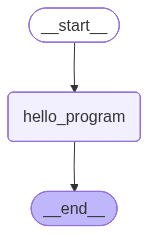

In [ ]:
from IPython.display import Image, display
display(Image(runnable.get_graph().draw_mermaid_png()))

In [ ]:
runnable.invoke({})

Hello World


{}

2. Create LangGraph Agent using Calculator Tool

In [ ]:
from langgraph.graph import StateGraph, END, START

In [ ]:
# Define a Calculator as Tool
def calculator_program(state):
    expression = state.get("expression", "")
    result = eval(expression)
    print(f"Result of {expression} is {result}")
    return state

In [ ]:
# Intialize the StateGraph
graph = StateGraph(dict)

# Add calculator_program program Node to the Graph
graph.add_node(calculator_program, name="calculator_program")

# Define start and end transactions
graph.add_edge(START, "calculator_program")

graph.add_edge("calculator_program", END)

# Execute the graph
runnable = graph.compile()

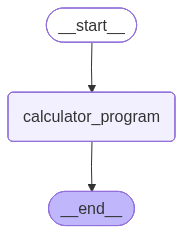

In [ ]:
from IPython.display import Image, display
display(Image(runnable.get_graph().draw_mermaid_png()))

In [ ]:
runnable.invoke({"expression": "(24 +10) * 3 / 4"})

Result of (24 +10) * 3 / 4 is 25.5


{'expression': '(24 +10) * 3 / 4'}

3. Create LLM

In [ ]:
import os
os.environ["GOOGLE_API_KEY"] = "AQ.Ab8RN6LXmiqvcGZlT7HJSy4pgaeAgLl62WT0a67NDh0nAzTdLA"

In [ ]:
import google.generativeai as genai
genai.configure(api_key = "AQ.Ab8RN6LXmiqvcGZlT7HJSy4pgaeAgLl62WT0a67NDh0nAzTdLA")

In [ ]:
for model in genai.list_models():
    print(model.name)

models/gemini-2.5-flash
models/gemini-2.5-pro
models/gemini-2.0-flash
models/gemini-2.0-flash-001
models/gemini-2.0-flash-lite-001
models/gemini-2.0-flash-lite
models/gemini-2.5-flash-preview-tts
models/gemini-2.5-pro-preview-tts
models/gemma-4-26b-a4b-it
models/gemma-4-31b-it
models/gemini-flash-latest
models/gemini-flash-lite-latest
models/gemini-pro-latest
models/gemini-2.5-flash-lite
models/gemini-2.5-flash-image
models/gemini-3-pro-preview
models/gemini-3-flash-preview
models/gemini-3.1-pro-preview
models/gemini-3.1-pro-preview-customtools
models/gemini-3.1-flash-lite-preview
models/gemini-3.1-flash-lite
models/gemini-3-pro-image-preview
models/gemini-3-pro-image
models/nano-banana-pro-preview
models/gemini-3.1-flash-image-preview
models/gemini-3.1-flash-image
models/gemini-3.1-flash-lite-image
models/gemini-3.5-flash
models/gemini-omni-flash-preview
models/lyria-3-clip-preview
models/lyria-3-pro-preview
models/gemini-3.1-flash-tts-preview
models/gemini-robotics-er-1.5-preview
mod

In [ ]:
from langchain_google_genai import ChatGoogleGenerativeAI

In [ ]:
llm = ChatGoogleGenerativeAI(
    model = "gemini-flash-lite-latest",
    temperature=0.7,
    max_tokens= 2048
)

4. Define a Node Function

In [ ]:
# Messages types used in langchain to represemt chat_messages like (User Input or AI Responses)
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage
# Appends new messages to the conversation state
from langgraph.graph import add_messages

In [ ]:
# class state will store list of messages whenever new messages are generated , this will automatically be added to this list.
class State(TypedDict):
    messages: Annotated[List[BaseMessage], add_messages]

In [ ]:
def chatbot(state: State) -> State:
    response = llm.invoke(state["messages"])
    return {"messages": [response]}

5. Build a Graph with LLM & Chatbot

In [ ]:
# Intialize the StateGraph
graph = StateGraph(State)

# Add calculator_program program Node to the Graph
graph.add_node(chatbot, name="chatbot")

# Define start and end transactions
graph.add_edge(START, "chatbot")

graph.add_edge("chatbot", END)

# Execute the graph
runnable = graph.compile()

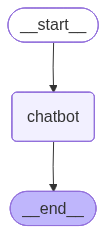

In [ ]:
from IPython.display import Image, display
# Visualize the Graph
display(Image(runnable.get_graph().draw_mermaid_png()))

In [ ]:
result = runnable.invoke(
    {"messages": [HumanMessage(content="What is the capital of France?")]}
)

In [ ]:
print(result["messages"][-1].content)

The capital of France is Paris.


In [ ]:
# New State of Graph Nose :
# Human : What is capital of France ?
# AI : Paris is the capital of France.

6. Multiple Nodes Graph Response

In [ ]:
class State(TypedDict):
    messages: Annotated[List[BaseMessage], add_messages]

In [ ]:
def chatbot(state):
    response = llm.invoke(state["messages"])
    return {"messages": [response]}

In [ ]:
def reviewer(state):
    review = AIMessage(
        content = "This response has been reviewed."
    )
    return {
        "messages": [review]
    }

In [ ]:
# Intialize the StateGraph
graph = StateGraph(State)

# Add calculator_program program Node to the Graph
graph.add_node(chatbot, name="chatbot")
graph.add_node(reviewer, name="reviewer")

# Define start and end transactions
graph.add_edge(START, "chatbot")
graph.add_edge("chatbot", "reviewer")
graph.add_edge("reviewer", END)

# Execute the graph
runnable = graph.compile()

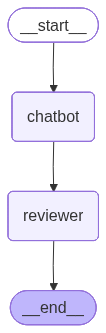

In [ ]:
from IPython.display import Image, display
# Visualize the Graph
display(Image(runnable.get_graph().draw_mermaid_png()))

In [ ]:
result = runnable.invoke(
    {"messages": [HumanMessage(content="What is the capital of France?")]}
)

In [ ]:
print(result["messages"][1].content)

The capital of France is Paris.


In [ ]:
print(result["messages"][2].content)

This response has been reviewed.
